# blog datas analyze
reference: https://keras.io/examples/nlp/multi_label_classification/

In [1]:
import pandas as pd
import numpy as np
from ast import literal_eval

In [2]:
# CSV 파일 불러오기
data = pd.read_csv("data/blog_tags_result.csv")

# 태그를 쉼표로 분리하여 리스트로 변환
data["tags"] = data["tags"].apply(lambda x: [tag.strip() for tag in str(x).split(',')])

data.head()

,link,title,tags
0,https://blog.banksalad.com/pnc/culture-faq/,"뱅크샐러드 채용, 무엇이든 물어보세요",[홍보]
1,https://blog.banksalad.com/pnc/design_dressing/,제1회 뱅크샐러드 디자인 드레싱을 소개합니다,[디자인]
2,https://blog.banksalad.com/pnc/mydata-handbook...,마이데이터 맵과 비즈니스 확장성,"[보안, 기획]"
3,https://blog.banksalad.com/pnc/hackathon_2022/,뱅크샐러드 사내 해커톤을 소개합니다!,[개발문화]
4,https://blog.banksalad.com/pnc/office-tour/,뱅크샐러드 오피스 투어 [업무공간 편],[홍보]


In [3]:
print(f"데이터셋에 {len(data)} 열이 있습니다")

데이터셋에 1092 열이 있습니다


In [4]:
total_duplicate_titles = sum(data["title"].duplicated())
print(f"중복 제목이 {total_duplicate_titles} 개 있습니다.")

중복 제목이 2 개 있습니다.


In [5]:
# 중복 제거
data = data[~data["title"].duplicated()]
print(f"중복 제거 후 데이터셋 행 수: {len(data)}")

# 모든 태그를 펼쳐서 빈도수 계산
from collections import Counter

all_tags = []
for tags in data["tags"]:
    all_tags.extend(tags)

# 개별 태그 빈도수 계산
tag_counts = Counter(all_tags)

# 1번만 등장하는 태그 개수
single_occurrence_tags = sum(1 for count in tag_counts.values() if count == 1)
print(f"1번만 등장하는 태그 수: {single_occurrence_tags}개")

# 고유 태그 수
print(f"총 고유 태그 수: {len(tag_counts)}개")
print(f"총 태그 발생 횟수: {len(all_tags)}회")

# 모든 태그 확인
print("\n=== 모든 태그 ===")
for tag, count in tag_counts.most_common():
    print(f"{tag}: {count}회")

중복 제거 후 데이터셋 행 수: 1090
1번만 등장하는 태그 수: 0개
총 고유 태그 수: 14개
총 태그 발생 횟수: 1951회

=== 모든 태그 ===
백엔드: 298회
프론트엔드: 296회
DevOps: 285회
컨퍼런스: 216회
데이터: 201회
모바일: 171회
AI: 141회
테스트: 92회
보안: 65회
개발문화: 63회
디자인: 58회
홍보: 31회
기획: 29회
기타: 5회


# multi-label text classification

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, ops

from sklearn.model_selection import train_test_split

from ast import literal_eval
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [7]:
# 처음 5개 데이터의 tags 확인
data["tags"].values[:5]

array([list(['홍보']), list(['디자인']), list(['보안', '기획']), list(['개발문화']),
       list(['홍보'])], dtype=object)

In [14]:
value_counts = data["tags"].value_counts()
valid_tags = value_counts[value_counts >= 2].index
filtered = data[data["tags"].isin(valid_tags)]

## 클래스 불균형을 고려하여 계층적 분할(stratified split)을 사용합니다

In [15]:
test_split = 0.1

# Initial train and test split.
train_df, test_df = train_test_split(
    filtered,
    test_size=test_split,
    stratify=filtered["tags"],
)

# Splitting the test set further into validation
# and new test sets.
val_df = test_df.sample(frac=0.5)
test_df.drop(val_df.index, inplace=True)

print(f"Number of rows in training set: {len(train_df)}")
print(f"Number of rows in validation set: {len(val_df)}")
print(f"Number of rows in test set: {len(test_df)}")

Number of rows in training set: 901
Number of rows in validation set: 50
Number of rows in test set: 51


## 멀티라벨 이진화

In [17]:
# For RaggedTensor
import tensorflow as tf

terms = tf.ragged.constant(train_df["tags"].values)
lookup = layers.StringLookup(output_mode="multi_hot")
lookup.adapt(terms)
vocab = lookup.get_vocabulary()


def invert_multi_hot(encoded_labels):
    """Reverse a single multi-hot encoded label to a tuple of vocab terms."""
    hot_indices = np.argwhere(encoded_labels == 1.0)[..., 0]
    return np.take(vocab, hot_indices)


print("Vocabulary:\n")
print(vocab)

Vocabulary:

['[UNK]', np.str_('백엔드'), np.str_('프론트엔드'), np.str_('DevOps'), np.str_('컨퍼런스'), np.str_('데이터'), np.str_('모바일'), np.str_('AI'), np.str_('테스트'), np.str_('개발문화'), np.str_('디자인'), np.str_('보안'), np.str_('홍보'), np.str_('기획'), np.str_('기타')]


In [19]:
sample_label = train_df["tags"].iloc[0]
print(f"Original label: {sample_label}")

label_binarized = lookup([sample_label])
print(f"Label-binarized representation: {label_binarized}")

Original label: ['AI', '컨퍼런스']
Label-binarized representation: [[0 0 0 0 1 0 0 1 0 0 0 0 0 0 0]]


In [20]:
train_df["title"].apply(lambda x: len(x.split(" "))).describe()

count    901.000000
mean       6.645949
std        2.542977
min        2.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       16.000000
Name: title, dtype: float64

In [26]:
max_seqlen = 8
batch_size = 128
padding_token = "<pad>"
auto = tf.data.AUTOTUNE


def make_dataset(dataframe, is_train=True):
    labels = tf.ragged.constant(dataframe["tags"].values)
    label_binarized = lookup(labels).numpy()
    dataset = tf.data.Dataset.from_tensor_slices(
        (dataframe["title"].values, label_binarized)
    )
    dataset = dataset.shuffle(batch_size * 10) if is_train else dataset
    return dataset.batch(batch_size)

In [27]:
train_dataset = make_dataset(train_df, is_train=True)
validation_dataset = make_dataset(val_df, is_train=False)
test_dataset = make_dataset(test_df, is_train=False)

In [29]:
text_batch, label_batch = next(iter(train_dataset))

for i, text in enumerate(text_batch[:5]):
    decoded = text.numpy().decode("utf-8")
    label = label_batch[i].numpy()[None, ...]
    print(f"Abstract: {decoded}")
    print(f"Label(s): {invert_multi_hot(label[0])}")
    print(" ")

Abstract: 토스의 접근성 문서 A11y Fundamentals 을 소개합니다 (오픈 기념 이벤트 ~9/10)
Label(s): ['프론트엔드' '테스트']
 
Abstract: NAVER Tech Talk: FE devtalk 12회 (2018년 8월)
Label(s): ['프론트엔드' '컨퍼런스']
 
Abstract: Code With Me를 활용한 페어 프로그래밍
Label(s): ['개발문화']
 
Abstract: 웹 폰트 사용과 최적화의 최근 동향
Label(s): ['프론트엔드' '컨퍼런스' '디자인']
 
Abstract: Basic of web [코딩카페]
Label(s): ['백엔드' '프론트엔드']
 


## 벡터화

In [32]:
vocabulary = set()
train_df["title"].str.lower().str.split().apply(vocabulary.update)
vocabulary_size = len(vocabulary)
print(vocabulary_size)

3096


In [33]:
text_vectorizer = layers.TextVectorization(
    max_tokens=vocabulary_size, ngrams=2, output_mode="tf_idf"
)

# `TextVectorization` layer needs to be adapted as per the vocabulary from our
# training set.
with tf.device("/CPU:0"):
    text_vectorizer.adapt(train_dataset.map(lambda text, label: text))

train_dataset = train_dataset.map(
    lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto
).prefetch(auto)
validation_dataset = validation_dataset.map(
    lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto
).prefetch(auto)
test_dataset = test_dataset.map(
    lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto
).prefetch(auto)

## 텍스트 분류 모델 만들기

In [34]:
def make_model():
    shallow_mlp_model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(256, activation="relu"),
            layers.Dense(lookup.vocabulary_size(), activation="sigmoid"),
        ]  # More on why "sigmoid" has been used here in a moment.
    )
    return shallow_mlp_model

## 모델 학습

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - binary_accuracy: 0.7996 - loss: 0.4832 - val_binary_accuracy: 0.8960 - val_loss: 0.3836
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.8932 - loss: 0.2994 - val_binary_accuracy: 0.9040 - val_loss: 0.3429
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9172 - loss: 0.2408 - val_binary_accuracy: 0.9040 - val_loss: 0.3107
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.9320 - loss: 0.1854 - val_binary_accuracy: 0.9173 - val_loss: 0.2860
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.9580 - loss: 0.1377 - val_binary_accuracy: 0.9187 - val_loss: 0.2697
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9710 - loss: 0.0997 - val_binary_accuracy: 0.9253 - val_loss: 0.2522
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.9809 - loss: 0.0695 - val_binary_accuracy: 0.9293 - val_loss: 0.2584
Epoch 8/20
8/8 ━━━━━━━━━━━━

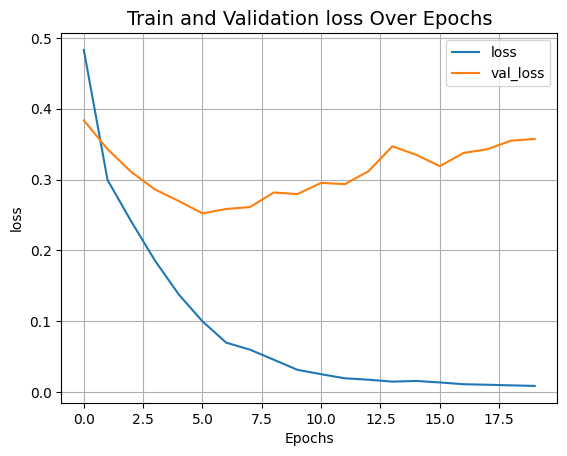

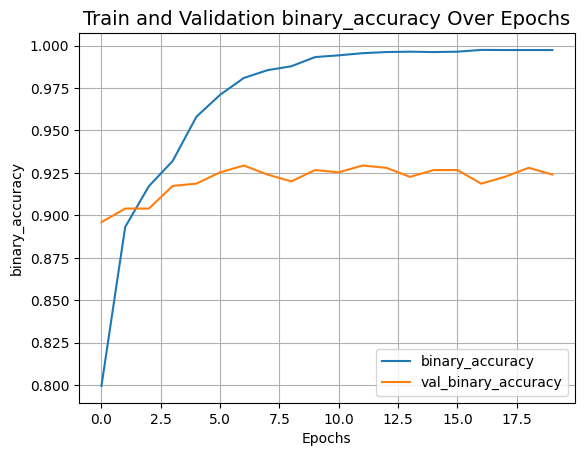

In [35]:
epochs = 20

shallow_mlp_model = make_model()
shallow_mlp_model.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["binary_accuracy"]
)

history = shallow_mlp_model.fit(
    train_dataset, validation_data=validation_dataset, epochs=epochs
)


def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("binary_accuracy")

In [37]:
_, binary_acc = shallow_mlp_model.evaluate(test_dataset)
print(f"Categorical accuracy on the test set: {round(binary_acc * 100, 2)}%.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - binary_accuracy: 0.9190 - loss: 0.4055
Categorical accuracy on the test set: 91.9%.


## 추론

In [36]:
# We create a custom Model to override the predict method so
# that it first vectorizes text data
class ModelEndtoEnd(keras.Model):

    def predict(self, inputs):
        indices = text_vectorizer(inputs)
        return super().predict(indices)


def get_inference_model(model):
    inputs = shallow_mlp_model.inputs
    outputs = shallow_mlp_model.outputs
    end_to_end_model = ModelEndtoEnd(inputs, outputs, name="end_to_end_model")
    end_to_end_model.compile(
        optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
    )
    return end_to_end_model


model_for_inference = get_inference_model(shallow_mlp_model)

# Create a small dataset just for demonstrating inference.
inference_dataset = make_dataset(test_df.sample(2), is_train=False)
text_batch, label_batch = next(iter(inference_dataset))
predicted_probabilities = model_for_inference.predict(text_batch)


# Perform inference.
for i, text in enumerate(text_batch[:5]):
    label = label_batch[i].numpy()[None, ...]
    print(f"Abstract: {text}")
    print(f"Label(s): {invert_multi_hot(label[0])}")
    predicted_proba = [proba for proba in predicted_probabilities[i]]
    top_3_labels = [
        x
        for _, x in sorted(
            zip(predicted_probabilities[i], lookup.get_vocabulary()),
            key=lambda pair: pair[0],
            reverse=True,
        )
    ][:3]
    print(f"Predicted Label(s): ({', '.join([label for label in top_3_labels])})")
    print(" ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Abstract: b'\xeb\x8d\xb0\xec\x9d\xb4\xed\x84\xb0 \xec\x84\xbc\xed\x84\xb0\xec\x97\x90 \xeb\x8c\x80\xed\x95\x9c \xec\x9d\xbc\xeb\xb0\x98 \xec\x83\x81\xec\x8b\x9d'
Label(s): ['DevOps' '데이터']
Predicted Label(s): (데이터, DevOps, 백엔드)
 
Abstract: b'\xed\x81\xb4\xeb\x9d\xbc\xec\x9a\xb0\xeb\x93\x9c \xed\x99\x98\xea\xb2\xbd\xec\x97\x90\xec\x84\x9c ARP \xec\x8a\xa4\xed\x91\xb8\xed\x95\x91 \xeb\xb0\xa9\xec\xa7\x80 \xeb\xa9\x94\xec\xbb\xa4\xeb\x8b\x88\xec\xa6\x98 \xea\xb5\xac\xed\x98\x84\xed\x95\x98\xea\xb8\xb0'
Label(s): ['DevOps' '보안']
Predicted Label(s): (DevOps, 백엔드, 데이터)
 
